# Scaling Techniques — Step by Step

## 1. Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler


## 2. Load data

In [2]:
df = pd.read_csv('data/loan_data.csv')
df.head()


,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


## 3. Define X and y, then split

In [3]:
x = df.drop(columns='loan_status')
y = df['loan_status']
xtrain, xtest, ytrain, ytest = train_test_split(x, y, train_size=0.8, random_state=42)
num_cols = x.select_dtypes(include='number').columns


## 4. Check outliers first

This decides which scaler to pick — StandardScaler/MinMaxScaler assume
few outliers, RobustScaler handles them better.

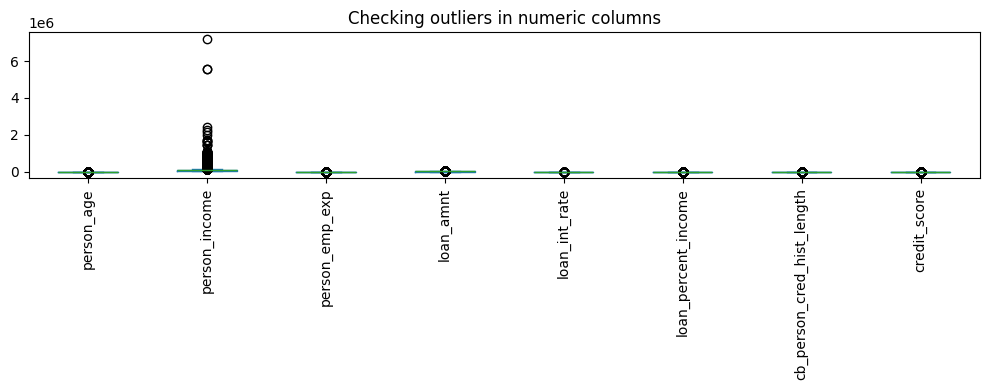

In [4]:
xtrain[num_cols].plot(kind='box', subplots=False, rot=90, figsize=(10, 4))
plt.title('Checking outliers in numeric columns')
plt.tight_layout()
plt.show()


## 5. StandardScaler

`z = (x - mean) / std` -> mean 0, std 1. Use for roughly normal data with
few outliers.

In [5]:
standard = StandardScaler()
standard_train = standard.fit_transform(xtrain[num_cols])   # fit_transform on TRAIN
standard_test = standard.transform(xtest[num_cols])          # transform only on TEST

pd.DataFrame(standard_train, columns=num_cols).describe().loc[['mean', 'std']]


,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score
mean,-7.855445e-17,-7.638334e-17,-1.578984e-18,1.034234e-16,-5.556049e-17,-1.188185e-16,-2.052679e-17,-6.550809e-16
std,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00


## 6. MinMaxScaler

`x' = (x - min) / (max - min)` -> scales to [0, 1]. Sensitive to
outliers — a single extreme value compresses everything else.

In [6]:
minmax = MinMaxScaler()
minmax_train = minmax.fit_transform(xtrain[num_cols])   # fit_transform on TRAIN
minmax_test = minmax.transform(xtest[num_cols])          # transform only on TEST

pd.DataFrame(minmax_train, columns=num_cols).describe().loc[['min', 'max']]


,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score
min,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
max,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


## 7. RobustScaler

`x' = (x - median) / IQR` -> uses median/IQR instead of mean/std, so it's
not skewed by outliers. Best choice when the boxplot above shows extreme
values.

In [7]:
robust = RobustScaler()
robust_train = robust.fit_transform(xtrain[num_cols])   # fit_transform on TRAIN
robust_test = robust.transform(xtest[num_cols])          # transform only on TEST

pd.DataFrame(robust_train, columns=num_cols).describe().loc[['50%']]


,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score
50%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 8. Compare all three side by side (first numeric column)

In [8]:
comparison = pd.DataFrame({
    'original': xtrain[num_cols[0]].reset_index(drop=True),
    'standard_scaled': standard_train[:, 0],
    'minmax_scaled': minmax_train[:, 0],
    'robust_scaled': robust_train[:, 0],
})
comparison.head()


,original,standard_scaled,minmax_scaled,robust_scaled
0,34.0,1.039475,0.112903,1.333333
1,25.0,-0.456186,0.040323,-0.166667
2,41.0,2.202767,0.169355,2.500000
3,27.0,-0.123817,0.056452,0.166667
4,27.0,-0.123817,0.056452,0.166667
